[![Colab Badge](https://img.shields.io/badge/Open_in_Colab-blue?style=for-the-badge)][colab-link]
<a href="javascript:void(0);" onclick="openJupyterWidget('https://github.com/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-pace/pace-opendap.ipynb');">
    <img src="https://img.shields.io/badge/Open_in_JupyterHub-orange?style=for-the-badge" alt="JupyterHub Badge">
</a> [![Download Badge](https://img.shields.io/badge/Download-grey?style=for-the-badge)][download-link]

[download-link]: https://nmfs-opensci.github.io/NMFSHackDays-2025/topics-2025/2025-pace/pace-opendap.ipynb
[colab-link]: https://colab.research.google.com/github/nmfs-opensci/nmfshackdays-2025/blob/main/topics-2025/2025-pace/pace-opendap.ipynb
[jupyter-link]: https://nmfs-openscapes.2i2c.cloud/hub/user-redirect/lab?fromURL=https://raw.githubusercontent.com/nmfs-opensci/nmfshackdays-2025/main/topics-2025/2025-pace/pace-opendap.ipynb

>📘 Learning Objectives
>
> 1. Show how to work with NASA OPeNDAP for PACE data
> 2. Create a NASA EDL session for authentication
> 3. Load single files with `xarray.open_dataset`
> 4. Load multiple files with `xarray.open_mfdataset`

## Overview

The PACE Level-3 (gridded) OCI (ocean color instrument) data is available on an OPeNDAP server <https://oceandata.sci.gsfc.nasa.gov/opendap/>. The full data are available on AWS via `earthaccess`.

NASA OPeNDAP servers (have nasa.gov in url) require Earthdata Login (EDL) authentication and some require an End User Licence Agreement (EULA). Here is the list of [NASA OPeNDAP servers](https://www.earthdata.nasa.gov/engage/open-data-services-software/earthdata-developer-portal/opendap/servers). There are Hyrax, GraDS and THREDDS servers. They behave slightly differently so it is good to know which one you are using.

### References

* <https://pydap.github.io/pydap/en/notebooks/PACE.html>
* <https://nmfs-opensci.github.io/NMFSHackDays-2025/topics-2025/2025-opendap/>

### Prerequisites

You need to have an EarthData Login username and password. Go here to get one <https://urs.earthdata.nasa.gov/>

I assume you have a `.netrc` file at `~` (home). `~/.netrc` should look just like this with your username and password. Create that file if needed. You don't need to create it if you don't have this file. The `earthaccess.login(persist=True)` line will ask for your username and password and create the `.netrc` file for you.

```
machine urs.earthdata.nasa.gov
        login yourusername
        password yourpassword
```


### Packages


In [3]:
import xarray as xr
import pydap.client

## Create a NASA EDL authenticated session

1. Authenticate with `earthaccess.login()` then create the session which will create the right headers when we (or `pydap`) does requests.

In [2]:
import earthaccess
earthaccess.login(persist=True)
edl_session = earthaccess.get_requests_https_session()

## PACE OPeNDAP server

Let's go to this oceancolor OPeNDAP server <https://oceandata.sci.gsfc.nasa.gov/opendap/>. It is Hyrax, which we can see in the footer. These have both DAP4 and DAP2 protocols. With `pydap`, you can specify `protocol="dap4"` so it knows which one to use. But `xarray.open_dataset()` doesn't accept the `protocol` argument so we need to use a work around.

We dig into the directory to find the PACE-OCI data and then look at the L3SMI directory:
https://oceandata.sci.gsfc.nasa.gov/opendap/PACE_OCI/L3SMI/2024/0301/contents.html

We will navigate to the `PACE_OCI.20240301_20240331.L3m.MO.AVW.V3_0.avw.0p1deg.nc` file in `2024/0301`. Here is the url which you will see when you click on the file and get to the "OPeNDAP DAP4 Data Request Form". This a monthly average.
```
url="http://oceandata.sci.gsfc.nasa.gov/opendap/PACE_OCI/L3SMI/2024/0301/PACE_OCI.20240301_20240331.L3m.MO.AVW.V3_0.avw.0p1deg.nc"
```

### Silence the DAP2 warning

Using `http` (or `https`) will open with with `dap4` and `pydap` which we are using to help with authentication will complain. We could replace `http` with `dap4` to use DAP4 but the variables would be garbled a bit; it is a bug with the DAP4.
```
dap4_url = url.replace("http", "dap4", 1)
```
Instead I will silence the DAP2 warning. It works just fine.


In [5]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="PyDAP was unable to determine the DAP protocol defaulting to DAP2.*",
    category=UserWarning,
    module="pydap.handlers.dap"
)

### Apparent Visible Wavelength (AVW)

AVW is not a derived geophysical variable, but instead an objective descriptor of the ocean’s color. This is a useful monitoring tool to assess if there are any changes to the color of the water, and if so, what direction the color is shifting (i.e. more red or more blue). It serves as an early indicator to detect changes in the optical water properties.



In [80]:
url="http://oceandata.sci.gsfc.nasa.gov/opendap/PACE_OCI/L3SMI/2024/0301/PACE_OCI.20240301_20240331.L3m.MO.AVW.V3_0.avw.0p1deg.nc"
ds = xr.open_dataset(url, engine="pydap", session=edl_session)
ds

<xarray.Dataset> Size: 26MB
Dimensions:  (lat: 1800, lon: 3600, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 7kB 89.95 89.85 89.75 89.65 ... -89.75 -89.85 -89.95
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    avw      (lat, lon) float32 26MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/62)
    product_name:                      PACE_OCI.20240301_20240331.L3m.MO.AVW....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    cdm_data_type:                     grid
    identifier_product_doi_authority:  http://dx.doi.org
    identifier_product_doi:            10.5067/PACE/OCI/L3M/AVW/3.0
    data_bins:                         Attribute elided: Unsupported attribut...
    data_minimum:                      399.999969
    data_maximum:                      700.000061

We can plot. Notice the order of the latitude. It goes from positive to negative.

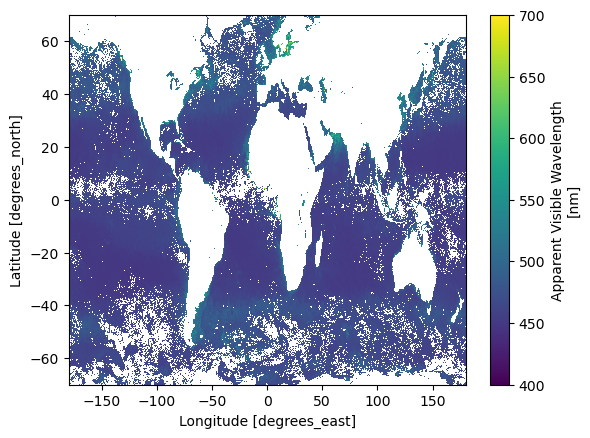

In [9]:
ds["avw"].sel(lat = slice(70, -70)).plot();

### Opening multiple files

Let's combine 3 months.

In [11]:
mar = "http://oceandata.sci.gsfc.nasa.gov/opendap/PACE_OCI/L3SMI/2024/0301/PACE_OCI.20240301_20240331.L3m.MO.AVW.V3_0.avw.0p1deg.nc"
apr = "http://oceandata.sci.gsfc.nasa.gov/opendap/PACE_OCI/L3SMI/2024/0401/PACE_OCI.20240401_20240430.L3m.MO.AVW.V3_0.avw.0p1deg.nc"
may = "http://oceandata.sci.gsfc.nasa.gov/opendap/PACE_OCI/L3SMI/2024/0501/PACE_OCI.20240501_20240531.L3m.MO.AVW.V3_0.avw.0p1deg.nc"
urls = [mar, apr, may]

In [16]:
ds = xr.open_mfdataset(
    urls, engine="pydap",
    combine='nested', concat_dim="time", 
    session=edl_session)

In [17]:
ds

<xarray.Dataset> Size: 78MB
Dimensions:  (time: 3, lat: 1800, lon: 3600, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 7kB 89.95 89.85 89.75 89.65 ... -89.75 -89.85 -89.95
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: time, rgb, eightbitcolor
Data variables:
    avw      (time, lat, lon) float32 78MB dask.array<chunksize=(1, 1800, 3600), meta=np.ndarray>
    palette  (time, rgb, eightbitcolor) uint8 2kB dask.array<chunksize=(1, 3, 256), meta=np.ndarray>
Attributes: (12/62)
    product_name:                      PACE_OCI.20240301_20240331.L3m.MO.AVW....
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    cdm_data_type:                     grid
    identifier_product_doi_authority:  http://dx.doi.org
    identifier_product_doi:            10.5067/PACE/OCI/L3M/AVW/3.0
    data_bins:                         Attribute elided: Unsupported attribut...
    data_minimum:                      399.999969
    data_maximum:                      700.000061

### Plot mean AVW over all longitudes (global) by latitude and month

In [18]:
lat_mean = ds["avw"].sel(lat = slice(70, -70)).mean(dim=["lon"])

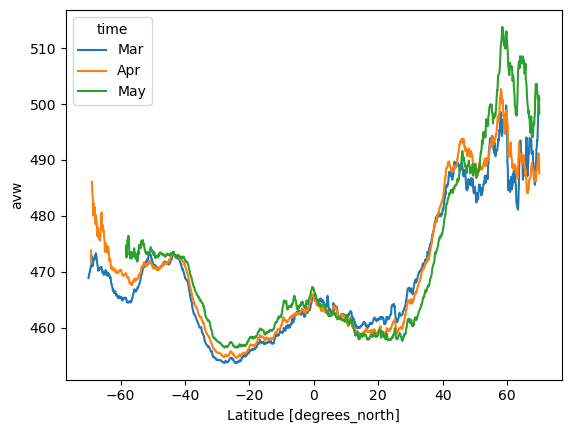

In [19]:
# Define custom labels for each time step
custom_time_labels = ["Mar", "Apr", "May"]  # Adjust based on actual time steps

# Assign new labels to the time coordinate
lat_mean = lat_mean.assign_coords({"time": custom_time_labels})

# Plot
lat_mean.plot.line(x="lat");

## Spectral phytoplankton absorption coefficients (aph)

We are going to get 4km data on Jan 1, 2025. This is rather massive (27 Gb) so we definitely want to subset before downloading.

We will get the plot at the Newport Line <https://www.st.nmfs.noaa.gov/copepod/time-series/us-50501/>: Latitude:   44.6517     Longitude:  -124.1770

In [82]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="PyDAP was unable to determine the DAP protocol defaulting to DAP2.*",
    category=UserWarning,
    module="pydap.handlers.dap"
)

import earthaccess
earthaccess.login(persist=True)
edl_session = earthaccess.get_requests_https_session()

import xarray as xr
url="http://oceandata.sci.gsfc.nasa.gov/opendap/PACE_OCI/L3SMI/2024/0801/PACE_OCI.20240801.L3m.DAY.IOP.V3_0.aph.4km.nc"
ds = xr.open_dataset(url, engine="pydap", session=edl_session)
ds

<xarray.Dataset> Size: 6GB
Dimensions:     (wavelength: 19, lat: 4320, lon: 8640, rgb: 3,
                 eightbitcolor: 256)
Coordinates:
  * wavelength  (wavelength) float64 152B 351.0 361.0 385.0 ... 678.0 711.0
  * lat         (lat) float32 17kB 89.98 89.94 89.9 ... -89.9 -89.94 -89.98
  * lon         (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    aph         (lat, lon, wavelength) float64 6GB ...
    palette     (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      PACE_OCI.20240801.L3m.DAY.IOP.V3_0.aph...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/IOP/3.0
    keywords:                          Earth Science > Oceans > Ocean Optics ...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         Attribute elided: Unsupported attribut...
    data_minimum:                      -0.776600242
    data_maximum:                      5.00000238

In [37]:
%%time
ds_np = ds['aph'].sel(lat=44.6517, lon=-124.1770, method='nearest')
ds_np.lon.values

CPU times: user 1.51 ms, sys: 0 ns, total: 1.51 ms
Wall time: 1.47 ms


array(-124.1875, dtype=float32)

In [ ]:
ds_np.plot()

### Multiple days

I could not get this to work.

In [48]:
urls = [
    f"http://oceandata.sci.gsfc.nasa.gov/opendap/PACE_OCI/L3SMI/2024/08{day:02d}/PACE_OCI.202408{day:02d}.L3m.DAY.IOP.V3_0.aph.4km.nc"
    for day in range(1, 7)
]
ds = xr.open_mfdataset(
    urls, engine="pydap",
    combine='nested', concat_dim="time", 
    session=edl_session)
ds

<xarray.Dataset> Size: 34GB
Dimensions:     (time: 6, lat: 4320, lon: 8640, wavelength: 19, rgb: 3,
                 eightbitcolor: 256)
Coordinates:
  * wavelength  (wavelength) float64 152B 351.0 361.0 385.0 ... 678.0 711.0
  * lat         (lat) float32 17kB 89.98 89.94 89.9 ... -89.9 -89.94 -89.98
  * lon         (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: time, rgb, eightbitcolor
Data variables:
    aph         (time, lat, lon, wavelength) float64 34GB dask.array<chunksize=(1, 4320, 8640, 19), meta=np.ndarray>
    palette     (time, rgb, eightbitcolor) uint8 5kB dask.array<chunksize=(1, 3, 256), meta=np.ndarray>
Attributes: (12/64)
    product_name:                      PACE_OCI.20240801.L3m.DAY.IOP.V3_0.aph...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/IOP/3.0
    keywords:                          Earth Science > Oceans > Ocean Optics ...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         Attribute elided: Unsupported attribut...
    data_minimum:                      -0.776600242
    data_maximum:                      5.00000238

In [46]:
# Cannot get this data to load
ds_np = ds['aph'].sel(lat=44.6517, lon=-124.1770, method='nearest')
ds_np


<xarray.DataArray 'aph' (time: 2, wavelength: 19)> Size: 304B
dask.array<getitem, shape=(2, 19), dtype=float64, chunksize=(1, 19), chunktype=numpy.ndarray>
Coordinates:
  * wavelength  (wavelength) float64 152B 351.0 361.0 385.0 ... 678.0 711.0
    lat         float32 4B 44.65
    lon         float32 4B -124.2
Dimensions without coordinates: time
Attributes:
    long_name:      Absorption due to phytoplankton
    units:          m^-1
    valid_min:      -24998
    valid_max:      25000
    reference:      P.J. Werdell, B.A. Franz, S.W. Bailey, G.C. Feldman and 1...
    display_scale:  log
    display_min:    0.00100000005
    display_max:    1.0

In [47]:
# this doesn't work
#ds_np.values

## Chlorophyl

<http://oceandata.sci.gsfc.nasa.gov/opendap/PACE_OCI/L3SMI/2024/0801/PACE_OCI.20240801.L3m.DAY.CHL.V3_0.chlor_a.4km.nc>

In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="PyDAP was unable to determine the DAP protocol defaulting to DAP2.*",
    category=UserWarning,
    module="pydap.handlers.dap"
)

import earthaccess
earthaccess.login(persist=True)
edl_session = earthaccess.get_requests_https_session()

import xarray as xr
url="http://oceandata.sci.gsfc.nasa.gov/opendap/PACE_OCI/L3SMI/2024/0801/PACE_OCI.20240801.L3m.DAY.CHL.V3_0.chlor_a.4km.nc"
ds = xr.open_dataset(url, engine="pydap", session=edl_session)
ds

<xarray.Dataset> Size: 149MB
Dimensions:  (lat: 4320, lon: 8640, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (lat, lon) float32 149MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      PACE_OCI.20240801.L3m.DAY.CHL.V3_0.chl...
    instrument:                        OCI
    title:                             OCI Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          PACE
    source:                            satellite observations from OCI-PACE
    ...                                ...
    identifier_product_doi:            10.5067/PACE/OCI/L3M/CHL/3.0
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         Attribute elided: Unsupported attribut...
    data_minimum:                      0.00122490886
    data_maximum:                      99.777832

In [71]:
print(f"Dataset size: {ds.nbytes/1e6:.2f} MB")

Dataset size: 149.35 MB


### Make a pretty plot

Why so much blank spaces? Clouds. This is not a gap-filled product.

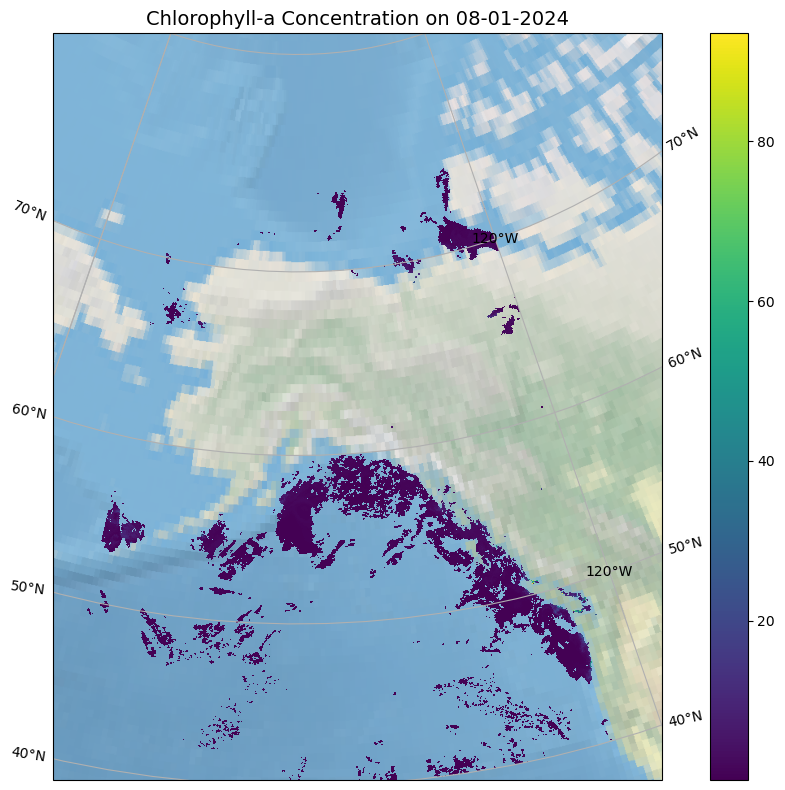

In [73]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select your region of interest
da = ds["chlor_a"].sel(lat=slice(80, 40), lon=slice(-170, -120))

# Set up the plot with Lambert Conformal projection
plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=-150))
ax.set_extent([-170, -120, 40, 80], crs=ccrs.PlateCarree())

# Optional: Add map background features
ax.stock_img()                 # Basic Earth background
#ax.coastlines(resolution='10m')  # Detailed coastlines if available
#ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.gridlines(draw_labels=True)

# Plot the chlorophyll-a data
da.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),  # Data is in lat/lon coords
    x='lon',
    y='lat',
    cmap='viridis',
    add_colorbar=True,
    add_labels=False
)

ax.set_title("Chlorophyll-a Concentration on 08-01-2024", fontsize=14)
plt.tight_layout()
plt.show()


## Conclusion

Working with NASA OPeNDAP servers using the `earthaccess` authenticated sessions, makes it easier to using xarray for single and multiple files.

## References

* [Pydap documentation](https://pydap.github.io/pydap/intro.html)
* [Pydap PACE tutorials](https://pydap.github.io/pydap/en/notebooks/PACE.html)
* [NASA OPeNDAP tutorials](https://github.com/OPENDAP/NASA-tutorials/tree/main)

